# Week 4 · SGLang 篇：第二引擎对决——前缀复用大战

> 🎯 **本周核心教学法**：同模型、同硬件、同 prompt，只换引擎——让"引擎"成为唯一变量。
> 本 Notebook 带你亲手部署 SGLang，并和 vLLM 打一场「前缀缓存」擂台赛。
>
> 前置理论：RadixAttention 基数树 / 连续批处理 / chunked prefill（见文字笔记 week-04）。

## 0. 理论速览：三个引擎级武器

| 技术 | 一句话 | 谁发明的 |
|---|---|---|
| 连续批处理 | 每个生成步重新组队，完成即走、排队即补 | Orca (OSDI 2022) |
| Chunked Prefill | 长 prompt 切片塞进 decode 的算力空档 | Sarathi-Serve (OSDI 2024) |
| RadixAttention | 基数树自动复用任意共享前缀的 KV | SGLang (NeurIPS 2024) |

**RadixAttention 核心**：KV cache 挂在树上，边=token 序列，共享前缀=公共路径；LRU 驱逐只踢叶子；命中率 0% 时零开销。

## 1. 双引擎共存指南（血泪经验）

SGLang 和 vLLM 的依赖会打架，本次实验踩过的坑：

```bash
# 坑1：sglang[all] 强升 torch 2.11→2.13，砸掉 vLLM 0.25.1 的 flash attention
# 坑2：vLLM 0.25.1 锁 torch 2.11，sglang 0.5.19 锁 torch 2.13 → 不可共存
# 解：vLLM 升级到 0.28.0（正好锁 torch==2.13.0，完美兼容）
pip install "vllm==0.28.0" "sglang[all]"

# 坑3：flashinfer-cubin 版本不匹配
export FLASHINFER_DISABLE_VERSION_CHECK=1

# 体检工具：依赖冲突一目了然
pip check
```

先确认当前两个引擎的状态：

In [1]:
import urllib.request, json

def engine_status(port, name):
    try:
        r = json.load(urllib.request.urlopen(f"http://localhost:{port}/v1/models", timeout=3))
        print(f"✅ {name} (: {port}) 运行中 → {[m['id'] for m in r['data']]}")
        return True
    except Exception:
        print(f"⭕ {name} (: {port}) 未运行")
        return False

vllm_up = engine_status(8000, "vLLM   ")
sglang_up = engine_status(8001, "SGLang")

if not (vllm_up or sglang_up):
    print()
    print("启动方式（终端执行，二选一，避免显存争抢）：")
    print("  vLLM:   bash /workspace/start_monitoring.sh")
    print("  SGLang: bash /workspace/start_sglang.sh")

⭕ vLLM    (: 8000) 未运行
✅ SGLang (: 8001) 运行中 → ['Qwen2.5-7B-Instruct']


## 2. 对决实验：共享前缀负载

**场景**：客服系统，所有请求共享 3360 token 的服务规范 system prompt。
**打法**：50 并发打两轮——第一轮冷缓存，第二轮应命中前缀缓存。
**看点**：TTFT（首字延迟）冷→热的变化幅度 = 前缀复用收益。

In [2]:
# 对决脚本已就位：/workspace/prefix_faceoff.py
# 内容：构造共享 system prompt，测两轮 TTFT 并对比
import subprocess, sys

def faceoff(url, name):
    """对一个引擎跑前缀对决，返回 (冷TTFT, 热TTFT)"""
    r = subprocess.run(
        [sys.executable, "/workspace/prefix_faceoff.py", "--url", url, "--name", name],
        capture_output=True, text=True, timeout=600)
    print(r.stdout)
    return r.stdout
    if r.returncode != 0:
        print(r.stderr[-500:])

# 👉 选择当前运行中的引擎做实验（改端口即可对另一个引擎重跑）
# faceoff("http://localhost:8000", "vLLM 0.28")
# faceoff("http://localhost:8001", "SGLang 0.5.19")
print("把上面两行的注释取消即可开跑（每轮约 1-2 分钟）")

把上面两行的注释取消即可开跑（每轮约 1-2 分钟）


## 3. 实机战报（2026-09-08 · RTX 5090 实测）

共享前缀 3360 token，50 并发 × 2 轮，max_tokens=32：

/tmp/ipykernel_3050/1699182775.py:18: UserWarning: Glyph 22359 (\N{CJK UNIFIED IDEOGRAPH-5757}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("/workspace/week04_faceoff.png", dpi=120); plt.show()
/tmp/ipykernel_3050/1699182775.py:18: UserWarning: Glyph 32531 (\N{CJK UNIFIED IDEOGRAPH-7F13}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("/workspace/week04_faceoff.png", dpi=120); plt.show()
/tmp/ipykernel_3050/1699182775.py:18: UserWarning: Glyph 23384 (\N{CJK UNIFIED IDEOGRAPH-5B58}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("/workspace/week04_faceoff.png", dpi=120); plt.show()


/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22359 (\N{CJK UNIFIED IDEOGRAPH-5757}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32531 (\N{CJK UNIFIED IDEOGRAPH-7F13}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23384 (\N{CJK UNIFIED IDEOGRAPH-5B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


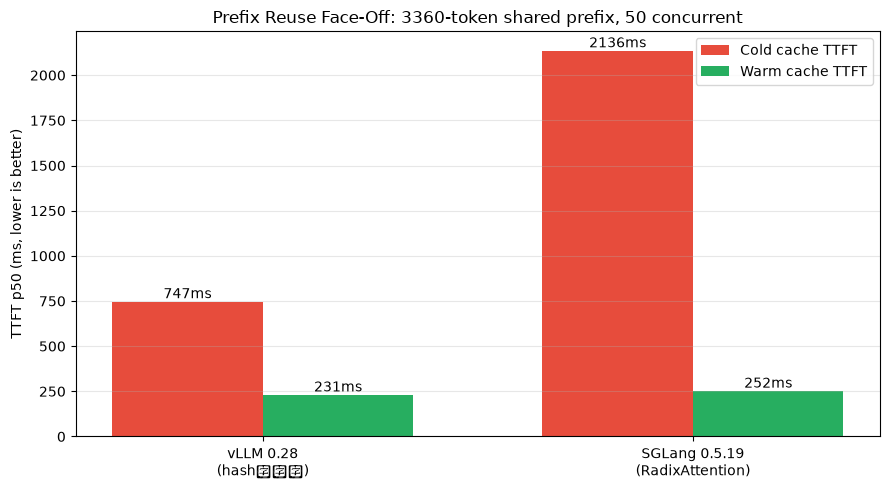

三个发现：
1. 热轮几乎打平（231 vs 252ms）——vLLM V1 已标配前缀缓存，5x 宣传已过时
2. vLLM 冷启动快 2.9x——chunked prefill + torch.compile 的 prefill 更强
3. 选型不是'谁快用谁'，而是'谁在你的负载特征上快'


In [3]:
# 实机数据（已录入，可随时重跑验证）
import matplotlib.pyplot as plt
import numpy as np

engines = ["vLLM 0.28\n(hash块缓存)", "SGLang 0.5.19\n(RadixAttention)"]
cold_ttft = [747, 2136]   # ms, p50
warm_ttft = [231, 252]    # ms, p50

x = np.arange(2); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, cold_ttft, w, label="Cold cache TTFT", color="#e74c3c")
b2 = ax.bar(x + w/2, warm_ttft, w, label="Warm cache TTFT", color="#27ae60")
ax.bar_label(b1, fmt="%dms"); ax.bar_label(b2, fmt="%dms")
ax.set_xticks(x); ax.set_xticklabels(engines)
ax.set_ylabel("TTFT p50 (ms, lower is better)")
ax.set_title("Prefix Reuse Face-Off: 3360-token shared prefix, 50 concurrent")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig("/workspace/week04_faceoff.png", dpi=120); plt.show()

print("三个发现：")
print("1. 热轮几乎打平（231 vs 252ms）——vLLM V1 已标配前缀缓存，5x 宣传已过时")
print("2. vLLM 冷启动快 2.9x——chunked prefill + torch.compile 的 prefill 更强")
print("3. 选型不是'谁快用谁'，而是'谁在你的负载特征上快'")

## 4. 亲手扩展实验（建议各做一次）

1. **多轮对话场景**：修改 `prefix_faceoff.py`，让第 N 轮请求带上前 N-1 轮的完整对话历史——RadixAttention 的主场，观察 SGLang 优势是否扩大
2. **同屏监控**：先 `bash start_monitoring.sh` 起 vLLM，Prometheus 配置里加一行 SGLang 的 `:8001/metrics`（两个引擎都吐 Prometheus 指标），Grafana 里同屏对比
3. **decode 对决**：本实验只比了 TTFT（prefill 主导）。把 max_tokens 改成 512，对比两者的 ITL（decode 主导）——猜猜谁会赢？

## 5. 排错工具箱（双引擎共存必备）

| 症状 | 原因 | 解法 |
|---|---|---|
| vLLM 启动 ImportError flash_attn | torch 被升级 | 对齐 vLLM 要求的 torch 版本 |
| flashinfer-cubin version mismatch | flashinfer 两个包不同步 | `FLASHINFER_DISABLE_VERSION_CHECK=1` |
| SGLang 显存不足 | vLLM 占了 90% | 先停一边，或 `--mem-fraction-static 0.4` |
| 不知道谁和谁冲突 | - | `pip check` |

## 6. 下一站

➡️ **Week 5 压测篇**：GuideLLM + genai-perf 系统性压测，找到系统的"拐点"（knee point），冲击 1000 并发。本周学的两个引擎将成为被测对象。